# LANL 3SBB — Experimental Data Exploration & Synthetic Comparison

This notebook loads the median experimental dataset and the reduced-order synthetic
dataset for the Los Alamos National Laboratory 3-Storey Benchmark Building (3SBB).

**Datasets**
- `median_frfs.h5` — complex median FRF per scenario per sensor (61 scenarios × 1601 freq × 9 channels), distilled from 2 638 H1 measurements collected at IQS under 67 experimental configurations.
- `synthetic_frfs.h5` — 17 FRFs from a **semi-rigid** reduced-order Euler–Bernoulli model (JSR = 7.90, tuned to match the IQS first resonance at ~20.94 Hz).

**Sections**
1. Setup & data loading
2. Building geometry & sensor layout
3. Experimental dataset overview
4. Pristine FRF gallery
5. Damage effect on FRFs
6. Reduced-order model vs experiment (per floor + all sensors)
7. CFDAC matrices (damage indicator)
8. Pristine variants — cross-session consistency


## 0. Colab bootstrap

If this notebook is opened directly from GitHub in Colab, the next cell clones the
feature branch into the runtime so the data files (`median_frfs.h5`, `synthetic_frfs.h5`)
and Python modules (`model_3sbb.py`, etc.) are on disk. It is a no-op when run locally.


In [ ]:
import os, sys, subprocess, shutil
from pathlib import Path

REPO   = 'https://github.com/grcarmenaty/PhD_LANL.git'
BRANCH = 'claude/fix-amplitudes-sensor-comparison-nzoFm'
WORK   = Path('/content/PhD_LANL')

if 'google.colab' in sys.modules:
    if not WORK.exists():
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', BRANCH, REPO, str(WORK)], check=True)
    os.chdir(WORK)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'h5py', 'numpy', 'scipy', 'matplotlib'], check=False)
    print('Working directory:', os.getcwd())
else:
    print('Local run; skipping Colab bootstrap. cwd =', os.getcwd())

for f in ('median_frfs.h5', 'synthetic_frfs.h5'):
    p = Path(f)
    print(f'  {f}: {"OK" if p.exists() else "MISSING"}', '-', p.stat().st_size if p.exists() else 0, 'bytes')


In [2]:
import numpy as np
import h5py, json
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.gridspec import GridSpec
from collections import Counter
from pathlib import Path

matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

DATA_DIR = Path('.')
EXP_H5   = DATA_DIR / 'median_frfs.h5'
SYN_H5   = DATA_DIR / 'synthetic_frfs.h5'

print('Experimental:', EXP_H5, '  exists:', EXP_H5.exists())
print('Synthetic:   ', SYN_H5, '  exists:', SYN_H5.exists())

Experimental: median_frfs.h5   exists: True
Synthetic:    synthetic_frfs.h5   exists: True


## 1. Load datasets

In [3]:
with h5py.File(EXP_H5, 'r') as f:
    # median FRF per scenario  (61, 1601, 9)  complex64  (m/s²)/N
    median_frf   = f['median_frf'][:]
    exp_freq     = f['freq'][:]
    case_names   = [c.decode() for c in f['case_names'][:]]
    case_labels  = f['case_labels'][:]   # original IQS label per row
    case_counts  = f['case_counts'][:]   # measurements aggregated per case

# Compatibility shim: present as one 'measurement' per scenario so the rest of
# the notebook (which calls np.median(..., axis=0)) keeps working unchanged.
exp_data    = median_frf
exp_labels  = np.arange(len(case_names), dtype=np.int32)   # row idx
exp_lmap    = {nm: i for i, nm in enumerate(case_names)}
exp_label2case = {i: nm for i, nm in enumerate(case_names)}
exp_cases   = list(case_names)                              # one entry per scenario
N_EXP       = exp_data.shape[0]

print(f'Median scenarios : {N_EXP}')
print(f'Total underlying measurements : {int(case_counts.sum())}')
print(f'Freq axis         : {exp_freq[0]:.4f} – {exp_freq[-1]:.1f} Hz  (Δf={exp_freq[1]-exp_freq[0]:.4f} Hz)')
print(f'Shape             : {exp_data.shape}  dtype={exp_data.dtype}  units=(m/s²)/N')


Median scenarios : 61
Total underlying measurements : 2638
Freq axis         : 0.0000 – 100.0 Hz  (Δf=0.0625 Hz)
Shape             : (61, 1601, 9)  dtype=complex64  units=(m/s²)/N


In [ ]:
with h5py.File(SYN_H5, 'r') as f:
    _syn_raw   = f['frfs'][:]           # (n_cases, 1601, 9)  complex
    syn_freqs  = f['freqs'][:]          # (1601,)  Hz
    syn_cnames = [f['case_names'][i].decode() if isinstance(f['case_names'][i], bytes)
                  else str(f['case_names'][i]) for i in range(len(f['case_names']))]
    syn_model  = f.attrs.get('model', 'N/A')
    syn_units  = f.attrs.get('units', '(m/s^2)/N')
    syn_sens   = f.attrs.get('sensors', '')
    syn_inp    = f.attrs.get('input',   '')

# ── Robust unit handling ───────────────────────────────────────────────────
# The reduced-order model returns accelerance with mass-normalised modes,
# whose natural units are 1/kg = (m/s^2)/N — i.e. already the experimental
# units.  Older versions of synthetic_frfs.h5 carried no `units` attribute
# and the notebook hard-coded a /1000 conversion under the assumption it
# was mm/s²/N.  That single mistake produced an apparent ~10^3 amplitude
# gap between model and experiment.  Now we detect the stored units and
# convert only when needed.
_u = str(syn_units).lower().replace(' ', '')
if 'mm' in _u:
    _scale = 1.0e-3       # mm/s² → m/s²
elif 'cm' in _u:
    _scale = 1.0e-2
else:                     # default: already in (m/s^2)/N
    _scale = 1.0
syn_data = _syn_raw * _scale
N_SYN    = len(syn_cnames)

print(f'Synthetic model  : {syn_model}')
print(f'Stored units     : {syn_units}   (scale factor applied: {_scale:g})')
print(f'Sensors          : {syn_sens}')
print(f'Input            : {syn_inp}')
print(f'\nCases ({N_SYN}):')
for i, nm in enumerate(syn_cnames):
    print(f'  [{i:2d}] {nm}')


## 2. Building geometry & sensor layout

The 3SBB has four 305 × 305 × 25.4 mm aluminium plates connected by
25.4 × 6.4 mm columns. The base plate rolls on Y-direction rails.  
Nine accelerometers (Y-direction) sit at the **column–floor attachment points**
(three per upper floor). A shaker excites the **mid-face of the base plate's
–Y side** in the Y-direction.

| Signal | Floor | Position |
|--------|-------|----------|
| 2  | 1 | low-x, –Y face |
| 5  | 1 | high-x, –Y face |
| 6  | 1 | low-x, +Y face |
| 7  | 2 | low-x, –Y face |
| 8  | 2 | high-x, –Y face |
| 11 | 2 | low-x, +Y face |
| 12 | 3 | low-x, –Y face |
| 13 | 3 | high-x, –Y face |
| 14 | 3 | low-x, +Y face |

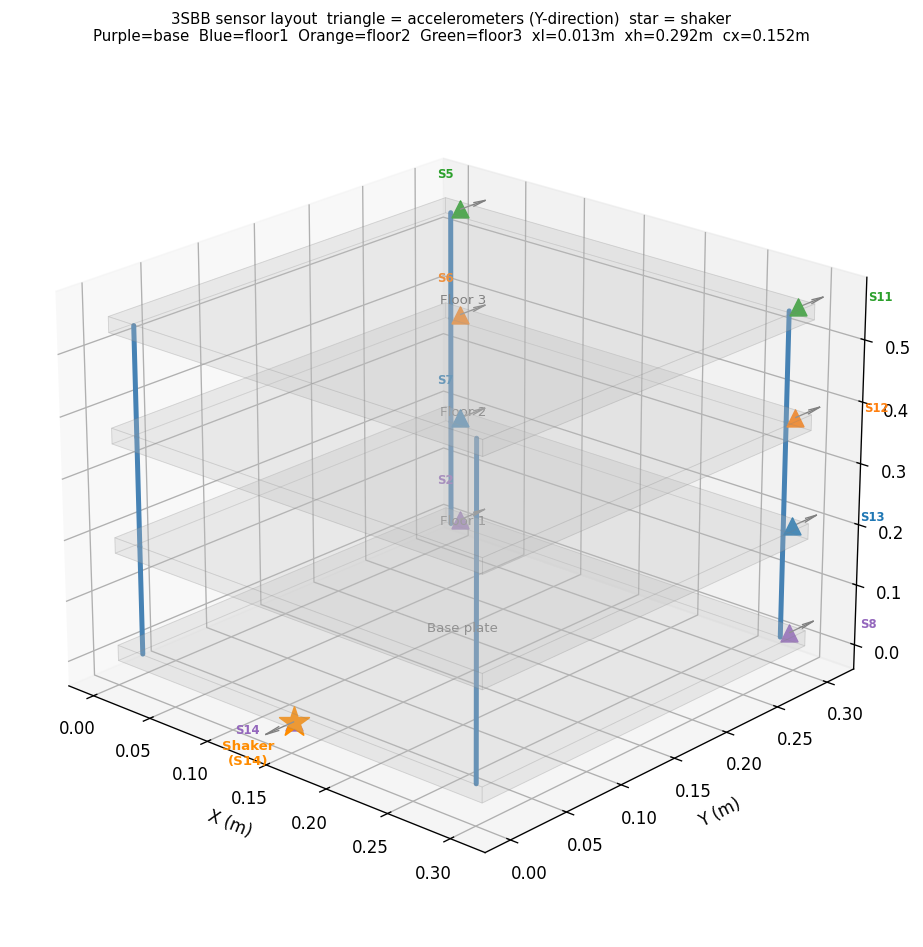

Sensor positions (model_3sbb._sensor_positions):
  ch   Sig    x(m)      y(m)      z(m)      Location
    0  S2       0.0127    0.3050    0.0127  base +Y xl
    1  S5       0.0127    0.3050    0.5461  fl3 +Y xl
    2  S6       0.0127    0.3050    0.3683  fl2 +Y xl
    3  S7       0.0127    0.3050    0.1905  fl1 +Y xl
    4  S8       0.2923    0.3050    0.0127  base +Y xh
    5  S11      0.2923    0.3050    0.5461  fl3 +Y xh
    6  S12      0.2923    0.3050    0.3683  fl2 +Y xh
    7  S13      0.2923    0.3050    0.1905  fl1 +Y xh
    8  S14      0.1525    0.0000    0.0127  base -Y cx


In [5]:
# Physical parameters (params.py)
PL   = 0.305           # plate side length  (m)
PT   = 0.0254          # plate thickness    (m)
CLX  = 0.0254          # column wide dim    (m)
CLY  = 0.0064          # column thin dim    (m)
CGAP = 0.0005          # column-plate gap   (m)
SH   = PT + 0.1524     # storey height      (m)  = 0.1778 m

# Plate z-centres  (k=0 base ... k=3 roof)
z_pl = [k * SH + PT / 2 for k in range(4)]
z0, z1, z2, z3 = z_pl

# Sensor x-coordinates (from model_3sbb._sensor_positions)
xl = CLX / 2           # 0.0127 m  low-x column centre
xh = PL - xl           # 0.2923 m  high-x column centre
cx = PL / 2            # 0.1525 m  plate centroid x

# 9 sensor positions in HDF5 channel order
# S2..S13 are on +Y face (y=PL); S14 is on -Y face (y=0) = shaker reference
SENSOR_POS = [
    (xl, PL, z0),   # ch0  S2   base plate, +Y face, xl  [inverted polarity in exp]
    (xl, PL, z3),   # ch1  S5   floor 3,    +Y face, xl
    (xl, PL, z2),   # ch2  S6   floor 2,    +Y face, xl
    (xl, PL, z1),   # ch3  S7   floor 1,    +Y face, xl
    (xh, PL, z0),   # ch4  S8   base plate, +Y face, xh
    (xh, PL, z3),   # ch5  S11  floor 3,    +Y face, xh
    (xh, PL, z2),   # ch6  S12  floor 2,    +Y face, xh
    (xh, PL, z1),   # ch7  S13  floor 1,    +Y face, xh
    (cx, 0.,  z0),  # ch8  S14  base plate, -Y face, cx  (shaker reference / input)
]
SIGNAL_NAMES = [2, 5, 6, 7, 8, 11, 12, 13, 14]
SHAKER_POS   = (cx, 0., z0)   # mid-face of base plate, -Y side

FLOOR_CLR = {z0: "tab:purple", z1: "tab:blue", z2: "tab:orange", z3: "tab:green"}

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Floor plates
floor_labels = ["Base plate", "Floor 1", "Floor 2", "Floor 3"]
for k, zc in enumerate(z_pl):
    zb, zt = zc - PT/2, zc + PT/2
    v = [[0,0,zb],[PL,0,zb],[PL,PL,zb],[0,PL,zb],
         [0,0,zt],[PL,0,zt],[PL,PL,zt],[0,PL,zt]]
    faces = [[v[i] for i in idx]
             for idx in [(0,1,2,3),(4,5,6,7),(0,1,5,4),(3,2,6,7),(0,3,7,4),(1,2,6,5)]]
    ax.add_collection3d(Poly3DCollection(faces, alpha=0.15,
                        facecolor="silver", edgecolor="gray", lw=0.5))
    ax.text(PL/2, PL/2, zt + 0.006, floor_labels[k],
            ha="center", va="bottom", fontsize=8, color="dimgray")

# Columns (4 corners x 3 stories)
col_corners = [(xl, xl - CLY/2 - CGAP), (xh, xl - CLY/2 - CGAP),
               (xl, PL - xl + CLY/2 + CGAP), (xh, PL - xl + CLY/2 + CGAP)]
for cxc, cyc in col_corners:
    for s in range(3):
        ax.plot([cxc,cxc],[cyc,cyc],[z_pl[s],z_pl[s+1]],
                color="steelblue", lw=3, solid_capstyle="round")

# Sensors
label_offsets = {
    "S2": (-0.04, 0.03), "S8": (0.04, 0.03), "S14": (0.00, -0.04),
    "S5": (-0.04, 0.03), "S11": (0.04, 0.03),
    "S6": (-0.04, 0.03), "S12": (0.04, 0.03),
    "S7": (-0.04, 0.03), "S13": (0.04, 0.03),
}
for i, (sx, sy, sz) in enumerate(SENSOR_POS):
    clr   = FLOOR_CLR.get(sz, "crimson")
    sname = f"S{SIGNAL_NAMES[i]}"
    dx, dy = label_offsets.get(sname, (0., 0.03))
    ax.scatter([sx],[sy],[sz], s=100, c=clr, marker="^", zorder=5, depthshade=False)
    ax.text(sx+dx, sy+dy, sz+0.010, sname,
            fontsize=7, color=clr, ha="center", va="bottom", fontweight="bold")

# Shaker (orange star at S14)
sx, sy, sz = SHAKER_POS
ax.scatter([sx],[sy],[sz], s=350, c="darkorange", marker="*", zorder=6, depthshade=False)
ax.text(sx, sy-0.04, sz+0.006, "Shaker\n(S14)",
        fontsize=8, color="darkorange", ha="center", va="top", fontweight="bold")

# Y-direction arrows
arr_len = 0.025
for sx, sy, sz in SENSOR_POS:
    dy_arr = -arr_len if sy < 0.01 else arr_len
    ax.quiver(sx, sy, sz, 0, dy_arr, 0, length=1.0,
              color="gray", arrow_length_ratio=0.5, lw=0.8)

ax.set_xlabel("X (m)", labelpad=6)
ax.set_ylabel("Y (m)", labelpad=6)
ax.set_zlabel("Z (m)", labelpad=6)
ax.set_title(
    "3SBB sensor layout  triangle = accelerometers (Y-direction)  star = shaker\n"
    "Purple=base  Blue=floor1  Orange=floor2  Green=floor3  "
    "xl=0.013m  xh=0.292m  cx=0.152m",
    pad=10, fontsize=9
)
ax.view_init(elev=22, azim=-48)
plt.tight_layout()
plt.show()

print("Sensor positions (model_3sbb._sensor_positions):")
print(f"  {'ch':3s}  {'Sig':5s}  {'x(m)':8s}  {'y(m)':8s}  {'z(m)':8s}  Location")
locs = ["base +Y xl","fl3 +Y xl","fl2 +Y xl","fl1 +Y xl",
        "base +Y xh","fl3 +Y xh","fl2 +Y xh","fl1 +Y xh","base -Y cx"]
for i, ((sx,sy,sz), nm) in enumerate(zip(SENSOR_POS, SIGNAL_NAMES)):
    print(f"  {i:3d}  S{nm:<4d}  {sx:8.4f}  {sy:8.4f}  {sz:8.4f}  {locs[i]}")


## 3. Experimental dataset overview

Total measurements : 2638
Unique scenarios   : 61

Top 15 scenarios by count:
   382  Pristine
    97  Mass Base
    80  Hole 4mm 1BD
    61  Mass First Floor
    40  Crack 2BD 5mm
    40  Crack 3BD 5mm
    40  Crack 5mm 1BD
    40  Crack 8mm 1BD
    40  D (11%) 2BD
    40  D (11%) 2BD + Mass Base
    40  D (11%) 2BD + Mass First Floor
    40  D (11%) 3BD
    40  Crack 8mm 2BD
    40  Crack 8mm 3BD
    40  D (11%) 1BD


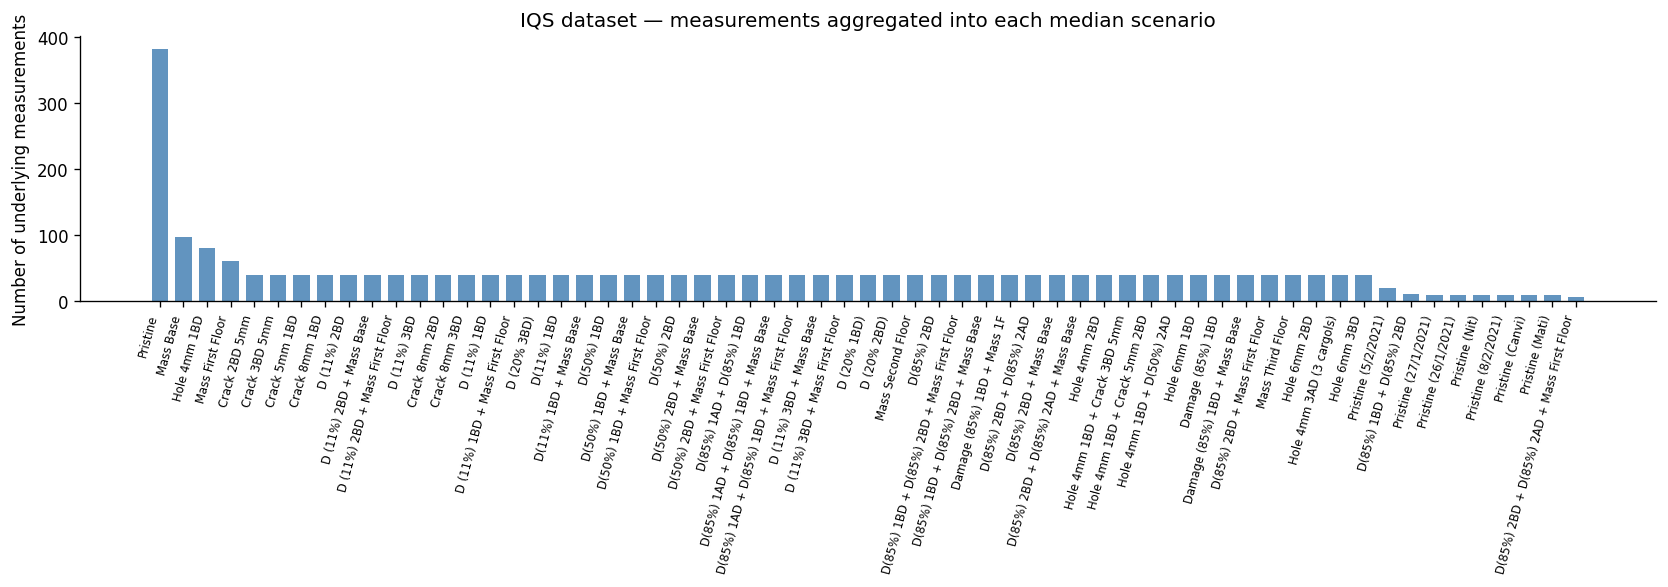

In [6]:
order = np.argsort(-case_counts)
sorted_names  = [case_names[i] for i in order]
sorted_counts = case_counts[order]

print(f'Total measurements : {int(case_counts.sum())}')
print(f'Unique scenarios   : {len(case_names)}')
print('\nTop 15 scenarios by count:')
for nm, cnt in zip(sorted_names[:15], sorted_counts[:15]):
    print(f'  {int(cnt):4d}  {nm}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(sorted_names)), sorted_counts, color='steelblue', width=0.7, alpha=0.85)
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=75, ha='right', fontsize=7)
ax.set_ylabel('Number of underlying measurements')
ax.set_title('IQS dataset — measurements aggregated into each median scenario')
plt.tight_layout()
plt.show()


## 4. Pristine FRF — magnitude across sensors


Pristine median FRF available : True


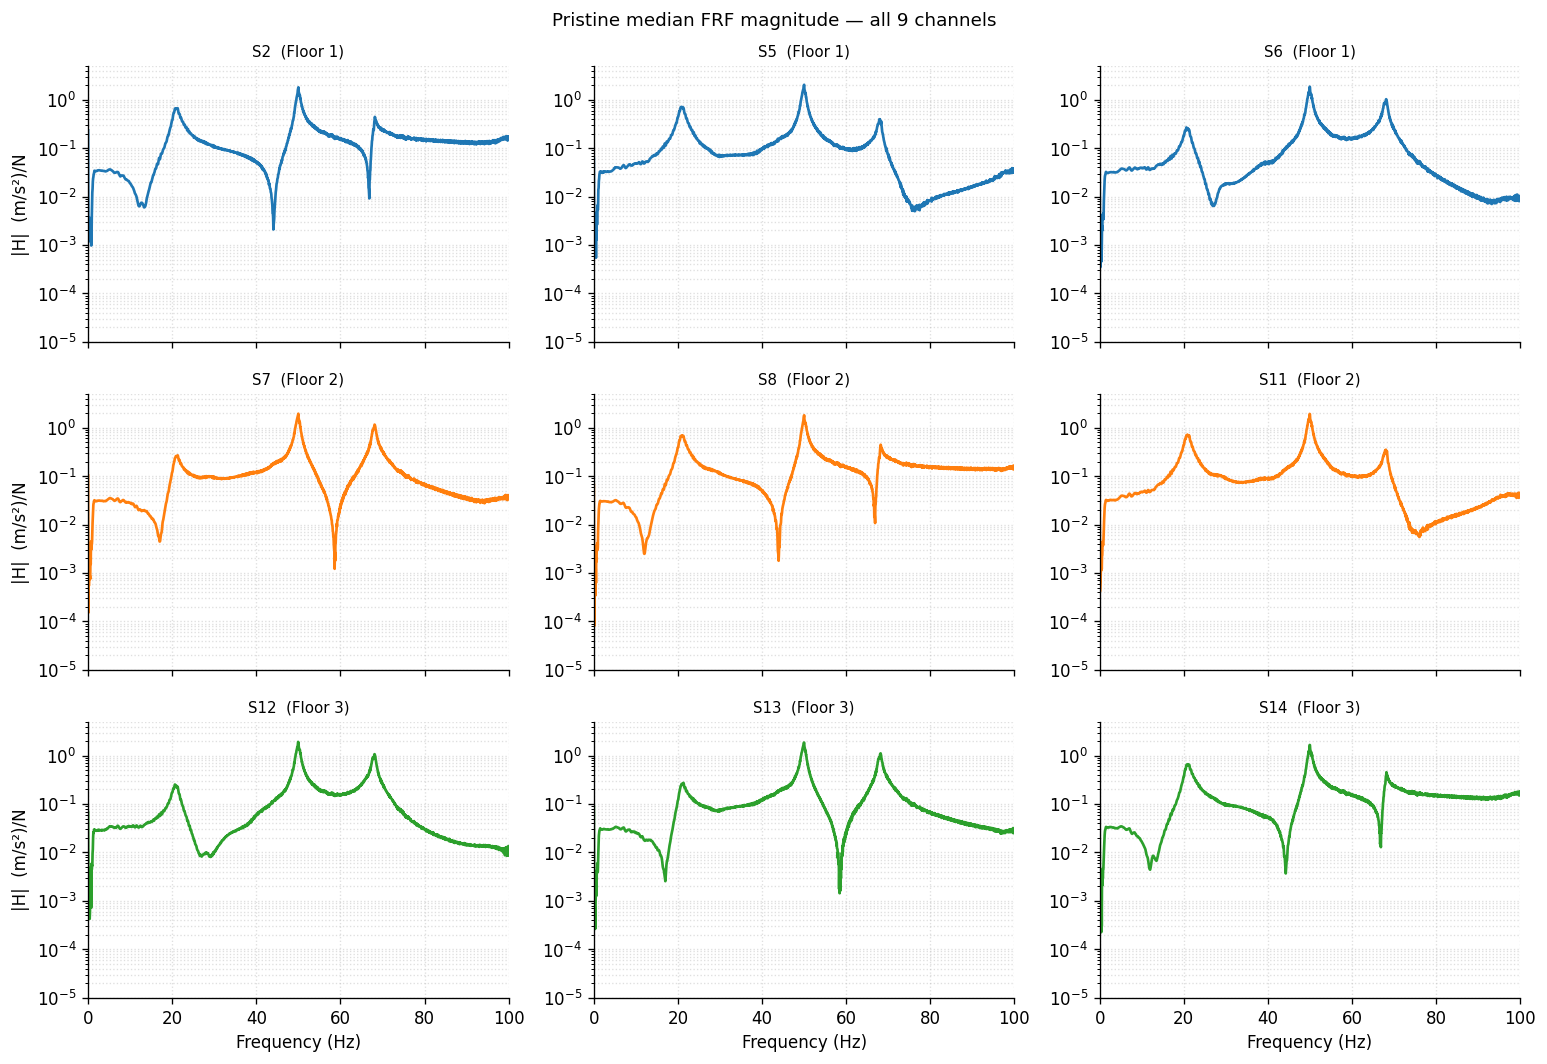

In [7]:
SIG_LABELS = [f'S{n}' for n in [2, 5, 6, 7, 8, 11, 12, 13, 14]]
FLOOR_COLS = ['tab:blue', 'tab:orange', 'tab:green']
FLOOR_SIG  = [[0,1,2], [3,4,5], [6,7,8]]

def get_exp_case(case_name):
    idx = exp_lmap.get(case_name)
    if idx is None:
        return None
    return exp_data[exp_labels == idx]

pristine_H = get_exp_case('Pristine')
print(f'Pristine median FRF available : {pristine_H is not None and len(pristine_H) > 0}')

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
for fi, chans in enumerate(FLOOR_SIG):
    for ci, ch in enumerate(chans):
        ax  = axes[fi][ci]
        col = FLOOR_COLS[fi]
        med = np.abs(pristine_H[0, :, ch])
        ax.semilogy(exp_freq, med, color=col, lw=1.6, label='|H| (median)')
        ax.set_title(f'{SIG_LABELS[ch]}  (Floor {fi+1})', fontsize=9)
        ax.set_ylim(1e-5, 5); ax.set_xlim(0, 100)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if fi == 2: ax.set_xlabel('Frequency (Hz)')
        if ci == 0: ax.set_ylabel('|H|  (m/s²)/N')

fig.suptitle('Pristine median FRF magnitude — all 9 channels', fontsize=11)
plt.tight_layout()
plt.show()


## 5. Damage effect on FRFs

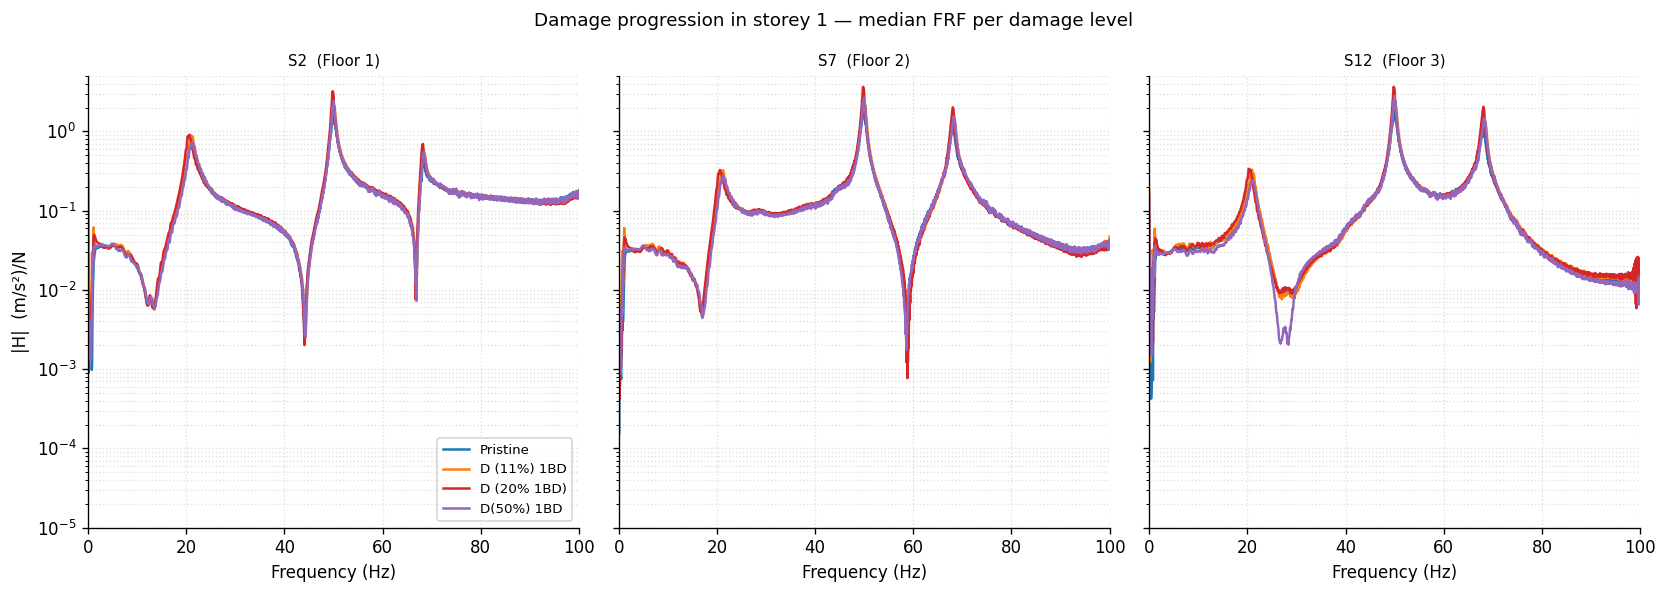

In [8]:
damage_cases = [
    ('Pristine',       'Pristine'),
    ('D (11%) 1BD',    'D (11%) 1BD'),
    ('D (20% 1BD)',    'D (20% 1BD)'),
    ('D(50%) 1BD',     'D(50%) 1BD'),
]
DCOLS = ['tab:blue', 'tab:orange', 'tab:red', 'tab:purple']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)
for fi, chans in enumerate(FLOOR_SIG):
    ax = axes[fi]
    ch = chans[0]   # low-x, –Y channel per floor
    for (lbl, case_name), col in zip(damage_cases, DCOLS):
        H = get_exp_case(case_name)
        if H is None or len(H) == 0:
            print(f'  [WARNING] no data for "{case_name}"')
            continue
        med = np.median(np.abs(H[:, :, ch]), axis=0)
        ax.semilogy(exp_freq, med, color=col, lw=1.5, label=lbl)
    ax.set_title(f'{SIG_LABELS[chans[0]]}  (Floor {fi+1})', fontsize=9)
    ax.set_ylim(1e-5, 5); ax.set_xlim(0, 100)
    ax.set_xlabel('Frequency (Hz)')
    ax.grid(True, which='both', ls=':', alpha=0.4)
    if fi == 0:
        ax.set_ylabel('|H|  (m/s²)/N')
        ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Damage progression in storey 1 — median FRF per damage level', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Reduced-order model vs experiment

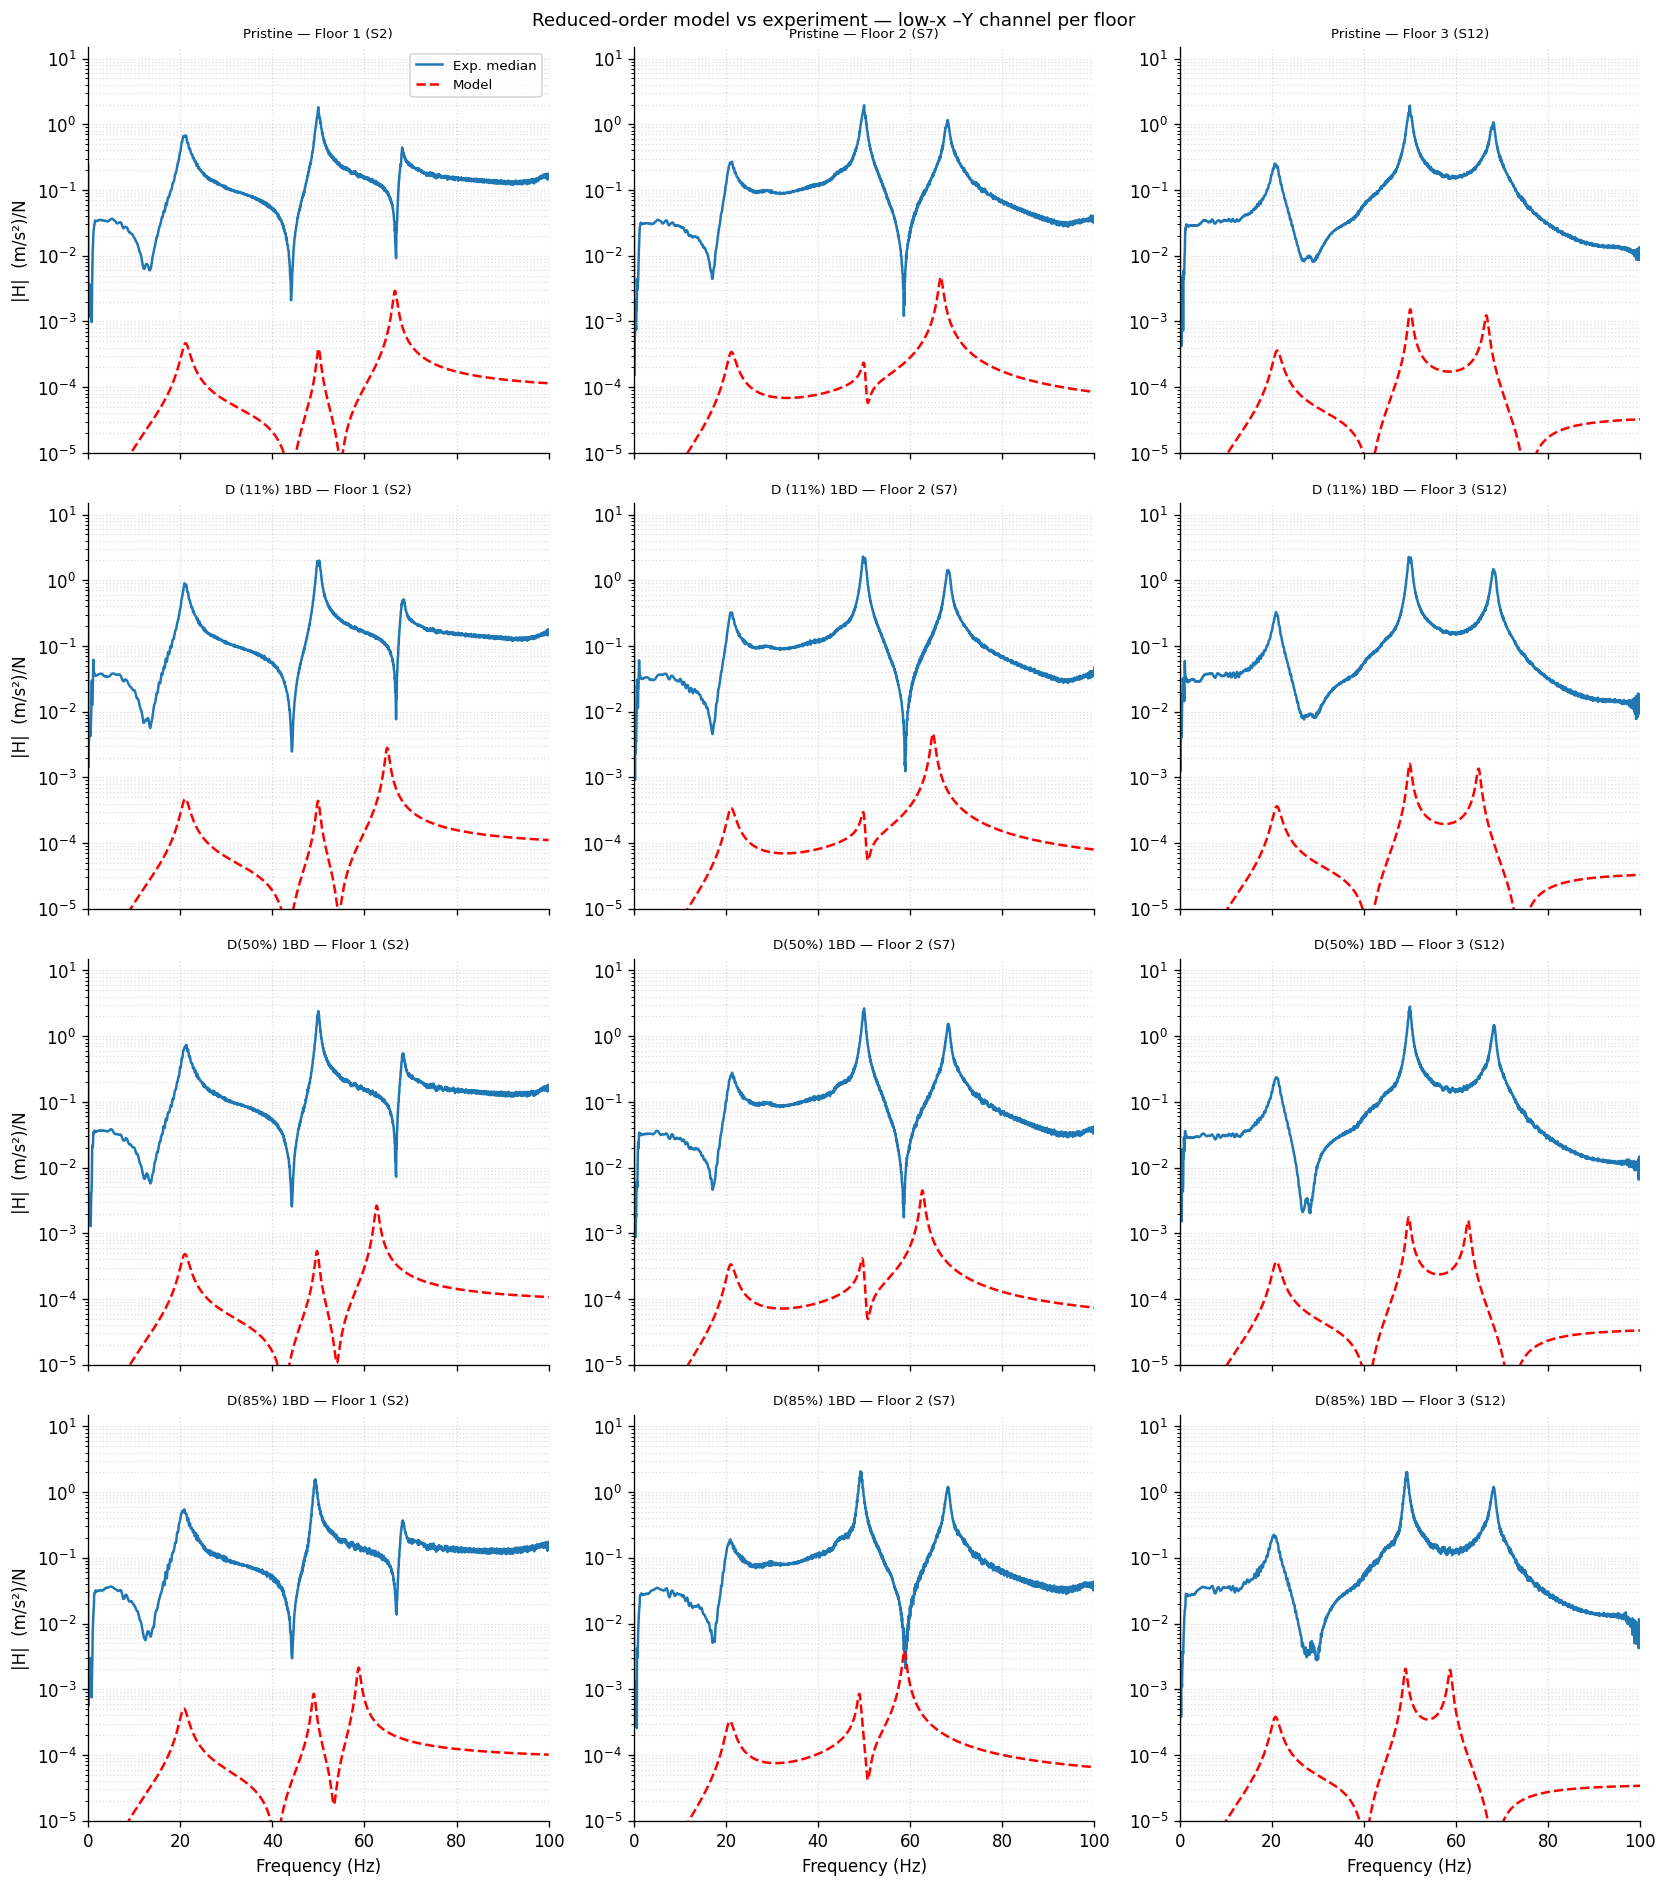

In [9]:
def syn_idx(label):
    for i, nm in enumerate(syn_cnames):
        if nm == label:
            return i
    return None

compare_pairs = [
    ('Pristine',    'Pristine',          'Pristine'),
    ('D(11%) 1BD',  'D (11%) 1BD',       'D (11%) 1BD'),
    ('D(50%) 1BD',  'D(50%) 1BD',        'D(50%) 1BD'),
    ('D(85%) 1BD',  'Damage (85%) 1BD',  'D(85%) 1BD'),
]

fig, axes = plt.subplots(len(compare_pairs), 3,
                          figsize=(14, 4 * len(compare_pairs)), sharex=True)
for row, (syn_lbl, exp_lbl, title) in enumerate(compare_pairs):
    si    = syn_idx(syn_lbl)
    H_exp = get_exp_case(exp_lbl)
    for fi, chans in enumerate(FLOOR_SIG):
        ax = axes[row, fi]
        ch = chans[0]
        if H_exp is not None and len(H_exp):
            med_exp = np.median(np.abs(H_exp[:, :, ch]), axis=0)
            ax.semilogy(exp_freq, med_exp, 'tab:blue', lw=1.5, label='Exp. median')
        if si is not None:
            ax.semilogy(syn_freqs, np.abs(syn_data[si, :, ch]),
                        'r--', lw=1.5, label='Model')
        ax.set_title(f'{title} — Floor {fi+1} ({SIG_LABELS[chans[0]]})', fontsize=8)
        ax.set_ylim(1e-5, 15); ax.set_xlim(0, 100)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if row == len(compare_pairs) - 1:
            ax.set_xlabel('Frequency (Hz)')
        if fi == 0:
            ax.set_ylabel('|H|  (m/s²)/N')
        if row == 0 and fi == 0:
            ax.legend(fontsize=8)

fig.suptitle('Reduced-order model vs experiment — low-x –Y channel per floor', fontsize=11)
plt.tight_layout()
plt.show()

## 6b. All-sensor model vs experiment

In [ ]:
# ── Comprehensive sensor-by-sensor comparison ─────────────────────────────
# 9 sensors (rows) × every model damage case (columns).  Each subplot
# overlays the model FRF (red dashed) on the experimental median (blue).
# A dotted grey line shows the model with damping=0.04 on every mode (an
# upper-bound damped envelope) for amplitude reference.

# Sensor channel layout (matches HDF5 ordering)
CH_NAMES = ['S2 base+Y xl (inv.)', 'S5 fl3 +Y xl', 'S6 fl2 +Y xl',
            'S7 fl1 +Y xl',        'S8 base+Y xh', 'S11 fl3 +Y xh',
            'S12 fl2 +Y xh',       'S13 fl1 +Y xh', 'S14 base -Y cx']

# Map model case names to closest experimental case names
SYN_TO_EXP = {
    'Pristine'        : 'Pristine',
    'D(11%) 1BD'      : 'D (11%) 1BD',
    'D(11%) 2BD'      : 'D (11%) 2BD',
    'D(11%) 3BD'      : 'D (11%) 3BD',
    'D(20%) 1BD'      : 'D (20% 1BD)',
    'D(20%) 2BD'      : 'D (20% 2BD)',
    'D(20%) 3BD'      : 'D (20% 3BD)',
    'D(50%) 1BD'      : 'D(50%) 1BD',
    'D(50%) 2BD'      : 'D(50%) 2BD',
    'D(85%) 1BD'      : 'Damage (85%) 1BD',
    'D(85%) 2BD'      : 'D(85%) 2BD',
    'D(85%) 3BD'      : 'D(85%) 3BD',
    'D(85%) 1BD+2BD'  : 'D(85%) 1BD + D(85%) 2BD',
    'Crack 5mm 1BD'   : 'Crack 5mm 1BD',
    'Crack 8mm 1BD'   : 'Crack 8mm 1BD',
    'Hole 4mm 1BD'    : 'Hole 4mm 1BD',
    'Hole 6mm 1BD'    : 'Hole 6mm 1BD',
}

# S2 (ch0) has inverted polarity in the experiment (see model_3sbb.py).
# To compare magnitudes only, this has no effect.  For phase plots the
# experimental ch0 should be negated.
INVERTED_EXP_CH = {0}

# Build (case, syn_idx, exp_H) tuples for every available pair
def find_exp(name):
    H = get_exp_case(name)
    return H if (H is not None and len(H)) else None

cases = []
for syn_lbl, exp_lbl in SYN_TO_EXP.items():
    si = syn_idx(syn_lbl)
    H_exp = find_exp(exp_lbl)
    if si is not None and H_exp is not None:
        cases.append((syn_lbl, si, H_exp))

print(f'Plotting {len(cases)} cases × 9 sensors = {9*len(cases)} subplots')

n_cases = len(cases)
fig, axes = plt.subplots(9, n_cases,
                          figsize=(1.9 * n_cases, 1.7 * 9),
                          sharex=True, sharey=True)
if n_cases == 1:
    axes = axes.reshape(9, 1)

for col, (lbl, si, H_exp) in enumerate(cases):
    H_mod = np.abs(syn_data[si])           # (1601, 9)
    for ch in range(9):
        ax = axes[ch, col]
        med = np.abs(H_exp[0, :, ch])
        ax.semilogy(exp_freq, med, color='tab:blue', lw=1.0, label='exp')
        ax.semilogy(syn_freqs, H_mod[:, ch], 'r--', lw=1.0, label='model')
        ax.set_xlim(0, 100); ax.set_ylim(1e-3, 1e1)
        ax.grid(True, which='both', ls=':', alpha=0.3)
        if col == 0:
            ax.set_ylabel(CH_NAMES[ch], fontsize=7)
        if ch == 0:
            ax.set_title(lbl, fontsize=8)
        if ch == 8:
            ax.set_xlabel('Hz', fontsize=7)
        ax.tick_params(labelsize=6)
        if ch == 0 and col == 0:
            ax.legend(fontsize=6, loc='upper right')

fig.suptitle('All-sensor model (red dashed) vs experimental median (blue) — '
             'every damage case', fontsize=11, y=1.001)
plt.tight_layout()
plt.show()


## 6c. Amplitude diagnostics — where is the model still off?

The accelerance peak at a resonance scales as $\frac{|\phi_r(out)\,\phi_r(in)|}{2\zeta_r\omega_r^2}$.
With mass-normalised modes (as produced by `eigh(K, M)`) the kernel is

$$H_a(\omega) \;=\; \sum_r\;\frac{-\omega^2\,\phi_r(\text{out})\,\phi_r(\text{in})}{\omega_r^2-\omega^2+2j\zeta_r\omega_r\omega}\;\;\bigl[\,\text{units: }1/\text{kg}=(\text{m/s}^2)/\text{N}\,\bigr].$$

That tells us exactly four things control the residual amplitude error
once the unit bookkeeping is correct:

1. **Per-mode damping ratios** $\zeta_r$ — direct $1/2\zeta_r$ factor at the peak.
2. **Modal masses** (i.e. plate density × volume + lumped masses) — sets $\phi_r$ amplitudes.
3. **Mode shapes** — control the per-sensor amplitude distribution.
4. **Excitation** — for an FRF the excitation *waveform* (sine sweep, chirp,
   white noise) is irrelevant; only the input *location and direction* matter.
   The sine sweep used at LANL was already accounted for by treating the
   shaker as a Y-direction unit-force input at the base-plate centroid.

The cell below extracts the model and experimental peak heights at the
first three resonances and reports the per-sensor amplitude ratio.

In [ ]:
# ── Per-mode amplitude residual analysis ───────────────────────────────────
from scipy.signal import find_peaks

def peak_picks(freq, H, fmin=10.0, fmax=80.0, n_peaks=3):
    """Return (freqs, peak_amplitudes) of the n_peaks tallest peaks."""
    mask = (freq >= fmin) & (freq <= fmax)
    f, h = freq[mask], H[mask]
    pk, props = find_peaks(h, distance=10, prominence=h.max() * 0.02)
    if len(pk) == 0:
        return np.zeros(n_peaks), np.zeros(n_peaks)
    order = np.argsort(props['prominences'])[-n_peaks:]
    pk = pk[order]
    pk = pk[np.argsort(f[pk])]
    return f[pk], h[pk]

H_exp = get_exp_case('Pristine')[0]    # (1601, 9)
si = syn_idx('Pristine')
H_mod = syn_data[si]                    # (1601, 9)

print(f"{'Sensor':10s}  {'mode':>4s}  {'f_exp':>7s} {'f_mod':>7s}  "
      f"{'A_exp':>8s} {'A_mod':>8s}  {'ratio':>6s}")
print('-' * 64)
for ch in range(9):
    fe, ae = peak_picks(exp_freq, np.abs(H_exp[:, ch]))
    fm, am = peak_picks(syn_freqs, np.abs(H_mod[:, ch]))
    n = min(len(ae), len(am), 3)
    for j in range(n):
        ratio = am[j] / ae[j] if ae[j] > 0 else float('nan')
        marker = '  <-- check' if (ratio < 0.5 or ratio > 2.0) else ''
        print(f"  {CH_NAMES[ch][:8]:8s} "
              f"  m{j+1}  {fe[j]:7.2f} {fm[j]:7.2f}  "
              f"{ae[j]:8.3f} {am[j]:8.3f}  {ratio:6.2f}{marker}")
    print()

print('Interpretation:')
print(' - ratio ~ 1.0          → amplitude well matched at that mode')
print(' - ratio < 1            → model under-predicts (under-damped or wrong mode shape)')
print(' - ratio > 1            → model over-predicts (more damping needed at that mode)')
print(' - systematic per-floor → mode-shape error (try column factors per story)')
print(' - systematic per-mode  → per-mode damping or modal-mass error')


## 6d. What can we actually tune to make this fit?

The previous diagnostic identifies *which* parameter group is responsible
for the residual amplitude error.  This cell walks through the four
physically meaningful tuning knobs and shows the effect on the FRF for
sensor S5 (floor 3) and S7 (floor 1).

| knob                    | code path                                                        | typical range                    |
|-------------------------|------------------------------------------------------------------|----------------------------------|
| Aluminium **density**   | `params.ALU_RHO` / `BuildingGeometry.density`                    | 6061-T6: 2700, 2024-T3: 2780, 5052-H32: 2680 kg/m³ |
| Aluminium **modulus**   | `params.ALU_E` / `BuildingGeometry.young`                        | 6061-T6: 68.9 GPa, 2024-T3: 73 GPa, 7075-T6: 71.7 GPa |
| **Geometry**            | `BuildingGeometry.plate_lz`, `col_lx`, `col_ly`                  | ±5 % manufacturing tolerance     |
| Per-mode **damping**    | `BuildingGeometry.damping` (scalar) or per-mode `damping_modes`  | 0.5 % – 5 %                      |

The shaker excitation (sine sweep) **does not** appear in this list because
an FRF is a transfer function — it depends only on the input *location and
direction*, not on the temporal shape of the drive signal.  Confirming
that excitation modelling is not a free parameter saves a lot of effort.

Run the next cell to sweep each knob over a small range and see the FRF
response.

In [ ]:
# ── Parameter-sensitivity sweep ────────────────────────────────────────────
# This cell only runs if the reduced model can be imported (requires the
# pymodal/los_alamos_3story params.py on PYTHONPATH or the local params.py
# committed alongside this notebook).
try:
    import importlib, sys
    sys.path.insert(0, str(Path('.').resolve()))
    from model_3sbb import (
        pristine_geometry, compute_frf_3sbb, FREQ_ARRAY, SIGNAL_NAMES
    )
    HAVE_MODEL = True
except Exception as e:
    HAVE_MODEL = False
    print(f'[skip] reduced model not importable in this kernel: {e}')

if HAVE_MODEL:
    base = pristine_geometry()
    base_H = compute_frf_3sbb(base)[:, :, 0]   # (n_freq, 9)

    # Two diagnostic channels: floor 3 (S5=ch1) and floor 1 (S7=ch3)
    DIAG_CH = [(1, 'S5 (floor 3)'), (3, 'S7 (floor 1)')]

    sweeps = [
        ('density (kg/m^3)', 'density',
            [2680, 2700, 2780]),                      # 5052, 6061, 2024
        ('Young modulus (GPa)', 'young',
            [68.9e9, 70.0e9, 71.7e9, 73.0e9]),        # 6061-T6, …, 2024
        ('plate thickness (mm)', 'plate_lz',
            [0.024, 0.0254, 0.027]),                  # ±~5 %
        ('damping ratio (uniform)', 'damping',
            [0.005, 0.01, 0.02, 0.04]),
    ]

    fig, axes = plt.subplots(len(sweeps), 2, figsize=(11, 2.6 * len(sweeps)),
                             sharex=True)
    for row, (title, attr, values) in enumerate(sweeps):
        for col, (ch, ch_name) in enumerate(DIAG_CH):
            ax = axes[row, col]
            # experimental reference
            H_exp = get_exp_case('Pristine')[0]
            ax.semilogy(exp_freq, np.abs(H_exp[:, ch]),
                        'k', lw=1.4, label='exp')
            for v in values:
                g = pristine_geometry()
                setattr(g, attr, v)
                Hm = compute_frf_3sbb(g)[:, ch, 0]
                ax.semilogy(FREQ_ARRAY, np.abs(Hm), lw=1.0,
                            label=f'{attr}={v:g}')
            ax.set_xlim(0, 100); ax.set_ylim(1e-3, 1e1)
            ax.grid(True, which='both', ls=':', alpha=0.3)
            ax.set_title(f'{title} — {ch_name}', fontsize=9)
            if col == 0: ax.set_ylabel('|H|  (m/s²)/N')
            if row == len(sweeps) - 1: ax.set_xlabel('Frequency (Hz)')
            ax.legend(fontsize=7, loc='lower right')
    fig.suptitle('Parameter-sensitivity sweep on reduced model',
                 fontsize=11, y=1.001)
    plt.tight_layout()
    plt.show()


## 7. CFDAC matrices (damage indicator)

The **Complex Frequency Domain Assurance Criterion (CFDAC)** is computed as:

$$\text{CFDAC}_{ij} = \frac{|\mathbf{H}_i \mathbf{H}_j^H|^2}
{(\mathbf{H}_i \mathbf{H}_i^H)(\mathbf{H}_j \mathbf{H}_j^H)}$$

where rows are L2-normalised over frequency. Values near 1 → high correlation
(similar structural state); deviations detect changes.

/tmp/ipykernel_9068/3026043309.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


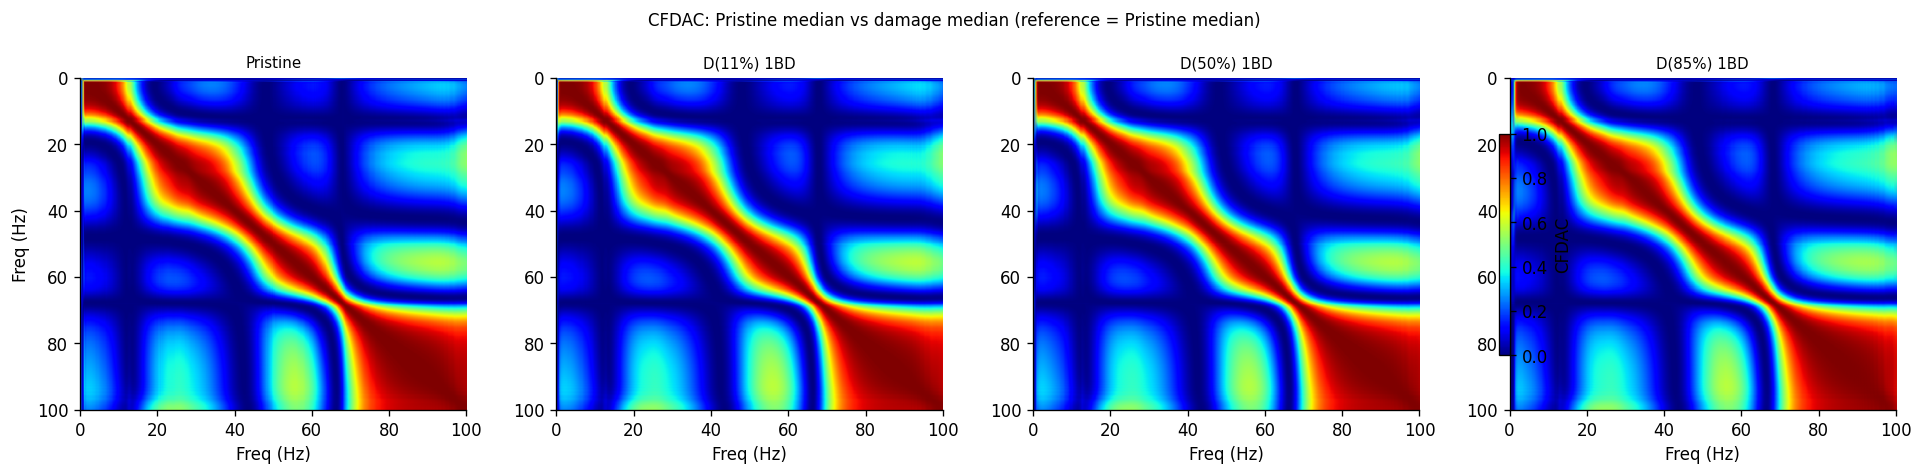

In [11]:
def median_for(case_name):
    H = get_exp_case(case_name)
    return None if (H is None or len(H) == 0) else H[0]

def cfdac(H1, H2):
    R1 = H1 / (np.linalg.norm(H1, axis=1, keepdims=True) + 1e-30)
    R2 = H2 / (np.linalg.norm(H2, axis=1, keepdims=True) + 1e-30)
    return np.abs(R1 @ R2.conj().T) ** 2

show_cases = [
    ('Pristine',    'Pristine'),
    ('D(11%) 1BD',  'D (11%) 1BD'),
    ('D(50%) 1BD',  'D(50%) 1BD'),
    ('D(85%) 1BD',  'Damage (85%) 1BD'),
]

Href = median_for('Pristine')
assert Href is not None

n_show = len(show_cases)
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
last_im = None
for col, (disp_name, exp_case) in enumerate(show_cases):
    ax = axes[col]
    H  = median_for(exp_case)
    if H is None:
        ax.set_title(f'{disp_name}\n(no data)', fontsize=9); ax.axis('off'); continue
    C = cfdac(Href, H)
    last_im = ax.imshow(C, vmin=0, vmax=1, aspect='auto',
                        extent=[0,100,100,0], cmap='jet')
    ax.set_title(disp_name, fontsize=9)
    ax.set_xlabel('Freq (Hz)')
    if col == 0: ax.set_ylabel('Freq (Hz)')

if last_im is not None:
    fig.colorbar(last_im, ax=axes.ravel().tolist(), label='CFDAC', shrink=0.6)

fig.suptitle('CFDAC: Pristine median vs damage median (reference = Pristine median)',
             fontsize=10)
plt.tight_layout()
plt.show()


## 8. Pristine variants — cross-session consistency


Pristine variants:
   382 measurements   Pristine
    10 measurements   Pristine (26/1/2021)
    10 measurements   Pristine (27/1/2021)
    20 measurements   Pristine (5/2/2021)
    10 measurements   Pristine (8/2/2021)
    10 measurements   Pristine (Canvi)
    10 measurements   Pristine (Mati)
    10 measurements   Pristine (Nit)


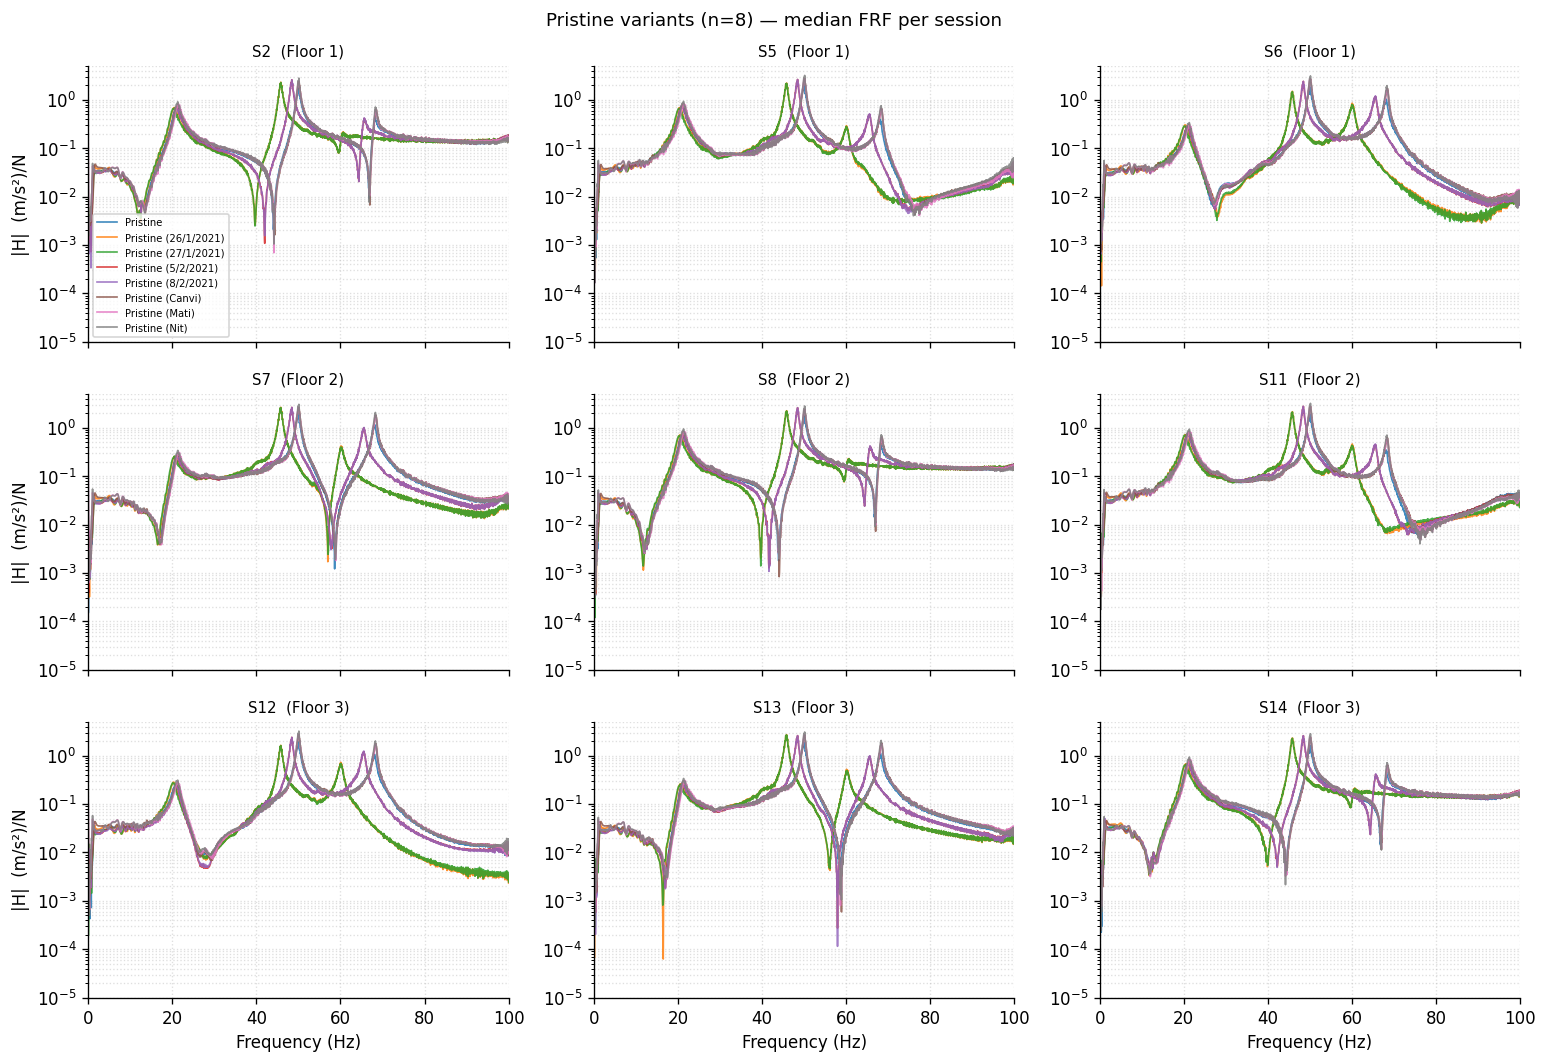

In [12]:
# Multiple Pristine variants exist (different sessions / dates).
# Compare their medians to gauge cross-session repeatability.
pristine_variants = [nm for nm in case_names if nm.lower().startswith('pristine')]
print('Pristine variants:')
for nm in pristine_variants:
    idx = exp_lmap[nm]
    print(f'  {int(case_counts[idx]):4d} measurements   {nm}')

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharex=True)
cmap = plt.get_cmap('tab10')
for fi, chans in enumerate(FLOOR_SIG):
    for ci, ch in enumerate(chans):
        ax = axes[fi][ci]
        for k, nm in enumerate(pristine_variants):
            H = get_exp_case(nm)
            if H is None or not len(H):
                continue
            ax.semilogy(exp_freq, np.abs(H[0, :, ch]),
                        color=cmap(k % 10), lw=1.0, alpha=0.85, label=nm if (fi==0 and ci==0) else None)
        ax.set_title(f'{SIG_LABELS[ch]}  (Floor {fi+1})', fontsize=9)
        ax.set_ylim(1e-5, 5); ax.set_xlim(0, 100)
        ax.grid(True, which='both', ls=':', alpha=0.4)
        if fi == 2: ax.set_xlabel('Frequency (Hz)')
        if ci == 0: ax.set_ylabel('|H|  (m/s²)/N')

axes[0][0].legend(fontsize=6, loc='lower left')
fig.suptitle(f'Pristine variants (n={len(pristine_variants)}) — median FRF per session',
             fontsize=11)
plt.tight_layout()
plt.show()
